# 07 — `export_model`

```
export_model.py
===============
Export model YOLO26 (object detection) terlatih ke format deploy.

Format didukung:
  - onnx        (simplify=True bila onnxslim/onnxsim tersedia, opset aman)
  - torchscript (export standar)
  - tensorrt    (OPSIONAL; hanya bila GPU CUDA + paket tensorrt tersedia)

Catatan: Ultralytics menyimpan file export di samping weights sumber; script ini
MEMINDAHKAN hasilnya ke folder output (runs/export) agar rapi.

Jalankan dari ROOT project (Windows):
    python src/export_model.py --weights runs/train/helmet_yolo26s_baseline/weights/best.pt --format onnx
    python src/export_model.py --weights ...best.pt --format torchscript
    python src/export_model.py --weights ...best.pt --format onnx,torchscript   (beberapa sekaligus)
    python src/export_model.py --weights ...best.pt --format tensorrt           (dilewati bila env tak siap)

Output:
    runs/export/<file hasil export>
    runs/export/export_summary.txt
```

Notebook ini adalah versi notebook dari [`src/export_model.py`](../src/export_model.py). Jalankan sel berurutan dari atas.

## Setup

In [3]:
# === Setup — jalankan sel ini lebih dulu ===
# Menemukan root project, menambahkan src/ ke sys.path, dan pindah (chdir) ke root
# agar semua path relatif (dataset/..., runs/...) berperilaku sama seperti
# menjalankan script dari root project.
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd         :", Path.cwd())

# === Auto-simpan grafik ke presentation_figures/ (otomatis tiap kali di-Run) ===
import matplotlib.pyplot as plt
_FIGDIR = PROJECT_ROOT / "presentation_figures"; _FIGDIR.mkdir(exist_ok=True)
_NB = "07_export_model"; _cnt = {"n": 0}
for _old in _FIGDIR.glob(_NB + "_*.png"):
    try: _old.unlink()
    except Exception: pass
_orig_show = getattr(plt, "_orig_show", plt.show); plt._orig_show = _orig_show
def _autosave_show(*a, **k):
    _f = plt.gcf()
    if _f.get_axes():
        _cnt["n"] += 1
        try: _f.savefig(_FIGDIR / (_NB + "_%02d.png" % _cnt["n"]), dpi=130, bbox_inches="tight")
        except Exception: pass
    return _orig_show(*a, **k)
plt.show = _autosave_show

PROJECT_ROOT: d:\ML\test-code\construction-safety-helmet-yolo26
cwd         : d:\ML\test-code\construction-safety-helmet-yolo26


## Apa yang dilakukan notebook ini
**Tujuan:** mengekspor `best.pt` ke format **siap-deploy** (lepas dari PyTorch).

**Format:** **ONNX** (`simplify` bila tersedia, `opset=12`), **TorchScript**, **TensorRT** (opsional; dilewati otomatis bila tak ada GPU CUDA / paket `tensorrt`).

**Output → `runs/export/`:** file model + `export_summary.txt`.

**Saat presentasi:** jelaskan kenapa export penting & trade-off format. Visual **ukuran file** + **paritas PT vs ONNX + latensi** ada di bagian bawah. Sel kode di bawah = isi lengkap [`src/export_model.py`](../src/export_model.py).

In [4]:
from __future__ import annotations

import argparse
import shutil
import sys
from datetime import datetime
from pathlib import Path

# Pemetaan nama format pengguna -> nama format Ultralytics.
FORMAT_MAP = {
    "onnx": "onnx",
    "torchscript": "torchscript",
    "tensorrt": "engine",
    "engine": "engine",
}

DEFAULTS = {
    "weights": "runs/train/helmet_yolo26s_baseline/weights/best.pt",
    "imgsz": 640,
    "device": "0",
    "format": "onnx",
    "output": "runs/export",
    "opset": 12,  # opset ONNX yang aman & kompatibel luas
}


def _line(char: str = "=", width: int = 64) -> str:
    return char * width


# --------------------------------------------------------------------------- #
# Pemeriksaan ketersediaan
# --------------------------------------------------------------------------- #
def simplify_available() -> tuple[bool, str]:
    """Cek apakah penyederhana ONNX (onnxslim/onnxsim) tersedia."""
    for mod in ("onnxslim", "onnxsim"):
        try:
            __import__(mod)
            return True, mod
        except ImportError:
            continue
    return False, ""


def module_available(name: str) -> bool:
    try:
        __import__(name)
        return True
    except Exception:
        return False


def resolve_device(device) -> tuple[object, bool, str]:
    """Return (effective_device, cuda_available, gpu_name)."""
    try:
        import torch
    except ImportError as exc:
        raise RuntimeError("PyTorch belum terinstal. Instal PyTorch dari pytorch.org.") from exc

    cuda = torch.cuda.is_available()
    if str(device).lower() == "cpu":
        return "cpu", cuda, "CPU"
    if cuda:
        idx = int(device) if str(device).isdigit() else 0
        try:
            name = torch.cuda.get_device_properties(idx).name
        except Exception:
            name = "GPU"
        return device, True, name
    # Diminta GPU tapi CUDA tak ada -> fallback CPU untuk format yang bisa (onnx/torchscript).
    print("[PERINGATAN] CUDA tidak tersedia. ONNX/TorchScript akan diexport di CPU; "
          "TensorRT akan dilewati.")
    return "cpu", False, "CPU"


# --------------------------------------------------------------------------- #
# Export satu format
# --------------------------------------------------------------------------- #
def export_one(weights: Path, fmt_user: str, imgsz: int, device, cuda_available: bool,
               out_dir: Path, opset: int, do_simplify: bool, half: bool) -> dict:
    """Export ke satu format. Selalu kembalikan dict hasil (tidak melempar)."""
    result = {"format": fmt_user, "status": "failed", "path": "", "size_mb": None, "note": ""}
    ul_fmt = FORMAT_MAP[fmt_user]

    # 7-8) TensorRT: jangan dipaksa bila environment belum siap.
    if ul_fmt == "engine":
        if not cuda_available:
            result.update(status="skipped", note="TensorRT butuh GPU CUDA; CUDA tidak tersedia.")
            print(f"  [SKIP] TensorRT dilewati: {result['note']}")
            return result
        if not module_available("tensorrt"):
            result.update(status="skipped",
                          note="Paket 'tensorrt' tidak terpasang. Instal TensorRT (sesuai versi CUDA) lalu ulangi.")
            print(f"  [SKIP] TensorRT dilewati: {result['note']}")
            return result

    try:
        from ultralytics import YOLO
    except ImportError as exc:
        result.update(status="failed", note=f"Ultralytics tak terimpor: {exc}")
        return result

    # Bangun argumen export.
    kwargs = {"format": ul_fmt, "imgsz": imgsz, "device": device}
    notes = []
    if ul_fmt == "onnx":
        if opset and opset > 0:
            kwargs["opset"] = opset
            notes.append(f"opset={opset}")
        kwargs["simplify"] = bool(do_simplify)
        notes.append(f"simplify={bool(do_simplify)}")
    if half and ul_fmt in ("onnx", "engine"):
        kwargs["half"] = True
        notes.append("half=True")

    print(f"  Export -> {fmt_user} ({', '.join(notes) if notes else 'standar'}) ...")
    try:
        model = YOLO(str(weights), task="detect")
        exported = Path(model.export(**kwargs))
    except Exception as exc:
        result.update(status="failed", note=f"{type(exc).__name__}: {exc}")
        print(f"  [ERROR] export {fmt_user} gagal: {exc}")
        return result

    # Pindahkan hasil ke out_dir agar rapi (export Ultralytics tersimpan di samping weights).
    dest = exported
    try:
        if exported.is_file():
            target = out_dir / exported.name
            if exported.resolve() != target.resolve():
                if target.exists():
                    target.unlink()
                shutil.move(str(exported), str(target))
                dest = target
    except Exception as exc:
        notes.append(f"gagal memindah ke output ({exc}); file tetap di {exported}")
        dest = exported

    size_mb = round(dest.stat().st_size / (1024 ** 2), 2) if dest.is_file() else None
    result.update(status="success", path=str(dest), size_mb=size_mb,
                  note="; ".join(notes))
    print(f"  [OK] {fmt_user} -> {dest}  ({size_mb} MB)")
    return result


# --------------------------------------------------------------------------- #
# Summary
# --------------------------------------------------------------------------- #
def build_summary(args, gpu_name, cuda_available, results: list[dict],
                  simplify_ok: bool, simplify_mod: str) -> str:
    L: list[str] = []
    L.append(_line())
    L.append("RINGKASAN EXPORT MODEL - YOLO26s (object detection)")
    L.append(_line())
    L.append(f"Waktu        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    L.append(f"Weights      : {args.weights}")
    L.append(f"imgsz        : {args.imgsz}")
    L.append(f"Device       : {args.device} ({gpu_name}, CUDA={'ya' if cuda_available else 'tidak'})")
    L.append(f"ONNX simplify: {'tersedia (' + simplify_mod + ')' if simplify_ok else 'tidak tersedia -> simplify dinonaktifkan'}")
    L.append("")
    L.append("HASIL EXPORT")
    L.append("-" * 64)
    L.append(f"{'format':<14}{'status':<10}{'size(MB)':>10}  path / catatan")
    for r in results:
        size = f"{r['size_mb']}" if r["size_mb"] is not None else "-"
        detail = r["path"] if r["status"] == "success" else r["note"]
        L.append(f"{r['format']:<14}{r['status']:<10}{size:>10}  {detail}")
    L.append("")

    ok = [r for r in results if r["status"] == "success"]
    skipped = [r for r in results if r["status"] == "skipped"]
    failed = [r for r in results if r["status"] == "failed"]
    L.append(f"Ringkas: {len(ok)} sukses, {len(skipped)} dilewati, {len(failed)} gagal.")
    if ok:
        L.append("")
        L.append("Model hasil export:")
        for r in ok:
            L.append(f"  - [{r['format']}] {r['path']}")
    if any(r["format"] in ("tensorrt", "engine") and r["status"] == "skipped" for r in results):
        L.append("")
        L.append("Catatan TensorRT: dilewati karena environment belum siap (butuh GPU CUDA + "
                 "paket 'tensorrt'). Ini perilaku yang diharapkan, bukan error.")
    L.append(_line())
    return "\n".join(L)


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #
def parse_formats(raw: str) -> tuple[list[str], list[str]]:
    """Parse string format (boleh dipisah koma). Return (valid, invalid)."""
    valid, invalid = [], []
    for tok in raw.split(","):
        t = tok.strip().lower()
        if not t:
            continue
        if t in FORMAT_MAP:
            if t not in valid:
                valid.append(t)
        else:
            invalid.append(t)
    return valid, invalid


def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Export model YOLO26 ke ONNX/TorchScript/TensorRT.")
    p.add_argument("--weights", default=DEFAULTS["weights"], help="Path best.pt.")
    p.add_argument("--format", default=DEFAULTS["format"],
                   help="onnx | torchscript | tensorrt (boleh dipisah koma, mis. onnx,torchscript).")
    p.add_argument("--imgsz", type=int, default=DEFAULTS["imgsz"])
    p.add_argument("--device", default=DEFAULTS["device"], help="0 untuk GPU, 'cpu' untuk CPU.")
    p.add_argument("--output", "-o", default=DEFAULTS["output"], help="Folder output (default runs/export).")
    p.add_argument("--opset", type=int, default=DEFAULTS["opset"],
                   help="Opset ONNX (default 12; 0 = biarkan Ultralytics memilih).")
    p.add_argument("--no-simplify", action="store_true", help="Nonaktifkan simplify ONNX.")
    p.add_argument("--half", action="store_true", help="Export FP16 (untuk onnx/tensorrt).")
    return p.parse_args(argv)


def main(argv: list[str] | None = None) -> int:
    args = parse_args(argv)
    out_dir = Path(args.output).resolve()

    print(_line())
    print("EXPORT MODEL YOLO26s - Construction Safety Helmet")
    print(_line())

    # 1) Validasi weights
    weights = Path(args.weights)
    if not weights.is_file():
        print(f"[ERROR] Weights tidak ditemukan: {weights}")
        print("        Latih model dulu (src/train.py) atau berikan --weights yang benar.")
        return 2

    # Parse format
    formats, invalid = parse_formats(args.format)
    if invalid:
        print(f"[PERINGATAN] format tidak dikenal diabaikan: {invalid} "
              f"(pilihan: {sorted(set(FORMAT_MAP))}).")
    if not formats:
        print("[ERROR] Tidak ada format valid. Gunakan: onnx, torchscript, tensorrt.")
        return 2

    # Device
    try:
        device, cuda_available, gpu_name = resolve_device(args.device)
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2

    # simplify availability (untuk ONNX)
    simplify_ok, simplify_mod = simplify_available()
    do_simplify = simplify_ok and not args.no_simplify

    print(f"Weights : {weights}")
    print(f"Device  : {args.device} ({gpu_name}, CUDA={'ya' if cuda_available else 'tidak'})")
    print(f"Format  : {formats}")
    if "onnx" in formats:
        print(f"ONNX    : simplify={'ya' if do_simplify else 'tidak'}"
              + ("" if simplify_ok else " (onnxslim/onnxsim tidak terpasang)")
              + f", opset={args.opset if args.opset > 0 else 'auto'}")
    print()

    out_dir.mkdir(parents=True, exist_ok=True)

    # 2-3) Export tiap format
    results: list[dict] = []
    for fmt in formats:
        print(_line("-"))
        print(f"FORMAT: {fmt}")
        print(_line("-"))
        try:
            res = export_one(weights, fmt, args.imgsz, device, cuda_available,
                             out_dir, args.opset, do_simplify, args.half)
        except KeyboardInterrupt:
            print("\n[INFO] Export dibatalkan oleh pengguna.")
            return 130
        except Exception as exc:  # safety net
            res = {"format": fmt, "status": "failed", "path": "", "size_mb": None,
                   "note": f"unexpected: {exc}"}
        results.append(res)

    # 4) Log summary
    summary = build_summary(args, gpu_name, cuda_available, results, simplify_ok, simplify_mod)
    summary_path = out_dir / "export_summary.txt"
    try:
        summary_path.write_text(summary, encoding="utf-8")
    except Exception as exc:
        print(f"[PERINGATAN] gagal menulis ringkasan: {exc}")

    print("\n")
    print(summary)
    print(f"\nRingkasan tersimpan di: {summary_path}")

    # 9) Exit code: 0 bila minimal satu sukses; 1 bila semua gagal (skip tidak dihitung gagal).
    n_ok = sum(1 for r in results if r["status"] == "success")
    n_failed = sum(1 for r in results if r["status"] == "failed")
    if n_ok == 0 and n_failed > 0:
        return 1
    return 0

## Jalankan
> Membutuhkan `best.pt`. Format bisa `onnx`, `torchscript`, atau `tensorrt`.

Argumen di bawah setara dengan opsi CLI. Edit sesuai kebutuhan.

In [5]:
rc = main(["--weights", "runs/train/helmet_yolo26s_baseline/weights/best.pt",
      "--format", "onnx"])
print("exit code:", rc)

EXPORT MODEL YOLO26s - Construction Safety Helmet
Weights : runs\train\helmet_yolo26s_baseline\weights\best.pt
Device  : 0 (NVIDIA GeForce RTX 4060 Ti, CUDA=ya)
Format  : ['onnx']
ONNX    : simplify=tidak (onnxslim/onnxsim tidak terpasang), opset=12

----------------------------------------------------------------
FORMAT: onnx
----------------------------------------------------------------
  Export -> onnx (opset=12, simplify=False) ...
Ultralytics 8.4.60  Python-3.11.9 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
YOLO26s summary (fused): 122 layers, 9,466,341 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from 'runs\train\helmet_yolo26s_baseline\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)

ONNX: starting export with onnx 1.21.0 opset 12...


d:\ML\test-code\construction-safety-helmet-yolo26\.venv\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success  1.5s, saved as 'runs\train\helmet_yolo26s_baseline\weights\best.onnx' (36.4 MB)

Export complete (2.2s)
Results saved to D:\ML\test-code\construction-safety-helmet-yolo26\runs\train\helmet_yolo26s_baseline\weights\best.onnx
Predict:         yolo predict task=detect model=runs\train\helmet_yolo26s_baseline\weights\best.onnx imgsz=640 
Validate:        yolo val task=detect model=runs\train\helmet_yolo26s_baseline\weights\best.onnx imgsz=640 data=dataset\data.yaml  
Visualize:       https://netron.app
  [OK] onnx -> D:\ML\test-code\construction-safety-helmet-yolo26\runs\export\best.onnx  (36.36 MB)


RINGKASAN EXPORT MODEL - YOLO26s (object detection)
Waktu        : 2026-06-12 16:37:35
Weights      : runs/train/helmet_yolo26s_baseline/weights/best.pt
imgsz        : 640
Device       : 0 (NVIDIA GeForce RTX 4060 Ti, CUDA=ya)
ONNX simplify: tidak tersedia -> simplify dinonaktifkan

HASIL EXPORT
----------------------------------------------------------------
format     

## Visualisasi deploy & *kenapa*
> ⚠️ **Catatan:** bila `best.pt` berasal dari *training DEMO* (subset kecil, sedikit epoch), angka di bawah **tidak mencerminkan performa nyata** — hanya untuk menunjukkan bentuk visualisasinya.

### a. Ukuran file model antar-format — *kenapa* format deploy berpengaruh

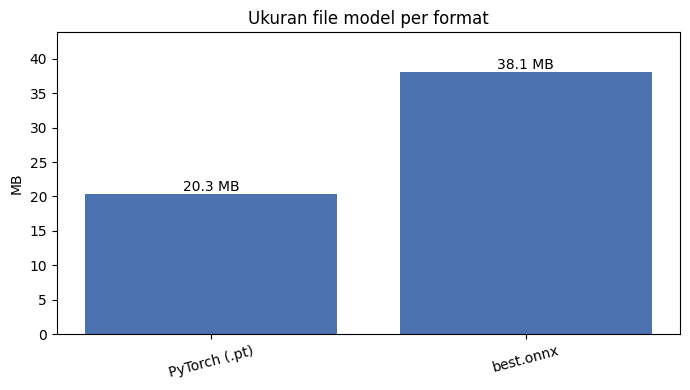

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
items = []
pt = Path("runs/train/helmet_yolo26s_baseline/weights/best.pt")
if pt.exists(): items.append(("PyTorch (.pt)", pt.stat().st_size/1e6))
for p in sorted(Path("runs/export").glob("*")):
    if p.suffix.lower() in {".onnx", ".torchscript"}:
        items.append((p.name, p.stat().st_size/1e6))
if not items:
    print("Belum ada file model — jalankan sel Run (export) dulu.")
else:
    labels = [a for a, _ in items]; sizes = [b for _, b in items]
    fig, ax = plt.subplots(figsize=(7, 4)); b = ax.bar(labels, sizes, color="#4c72b0")
    for bb, v in zip(b, sizes): ax.text(bb.get_x()+bb.get_width()/2, v, f"{v:.1f} MB", ha="center", va="bottom")
    ax.set_title("Ukuran file model per format"); ax.set_ylabel("MB"); ax.tick_params(axis="x", rotation=15); ax.margins(y=0.15)
    plt.tight_layout(); plt.show()

### b. Paritas PyTorch vs ONNX & latensi — *kenapa* export aman + trade-off kecepatan
Menjalankan `.pt` dan `.onnx` pada gambar sama, membandingkan jumlah deteksi & mengukur latensi rata-rata (CPU).

Loading runs\export\best.onnx for ONNX Runtime inference...
requirements: Ultralytics requirement ['onnxruntime'] not found, attempting AutoUpdate...
Resolved 5 packages in 359ms
 Downloaded onnxruntime
Prepared 2 packages in 571ms
Installed 2 packages in 186ms
 + flatbuffers==25.12.19
 + onnxruntime==1.26.0

requirements: AutoUpdate success  1.5s
WARNING requirements: Restart runtime or rerun command for updates to take effect

Using ONNX Runtime 1.26.0 with CPUExecutionProvider


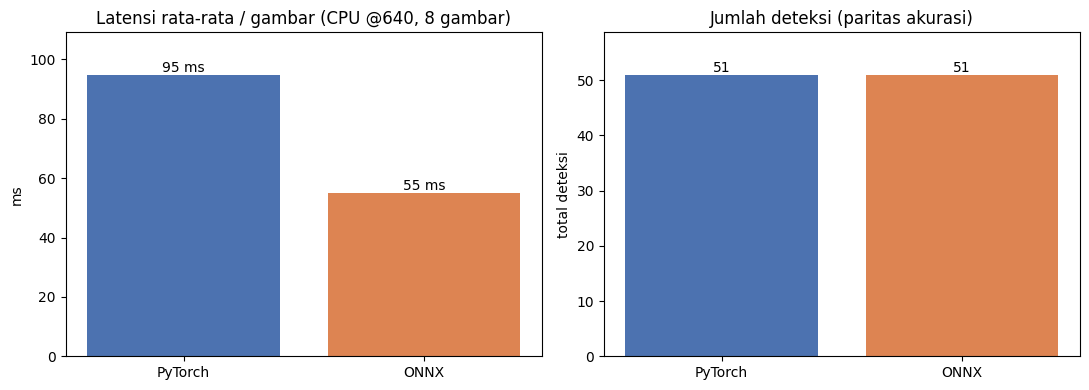

PyTorch: 51 deteksi | ONNX: 51 deteksi (harus mendekati sama => export tidak merusak akurasi).


In [7]:
from pathlib import Path
import time, numpy as np, matplotlib.pyplot as plt
pt = Path("runs/train/helmet_yolo26s_baseline/weights/best.pt")
onnx = next(iter(Path("runs/export").glob("*.onnx")), None)
ok = True
try:
    from ultralytics import YOLO
    import eda
except Exception as e:
    ok = False; print("ultralytics belum ada:", e)
if ok and not pt.exists(): ok = False; print("best.pt belum ada.")
if ok and onnx is None: ok = False; print("file .onnx belum ada - jalankan sel Run (export onnx) dulu.")
if ok:
    data, class_names, nc, root = eda.load_dataset_config("dataset/data.yaml")
    vimg, _ = eda.resolve_splits(root, data).get("valid", (None, None))
    imgs = [str(q) for q in sorted(vimg.iterdir())[:8] if q.suffix.lower() in {".jpg", ".jpeg", ".png"}]
    IMGSZ = 640  # ONNX diekspor pada 640 dengan batch tetap 1 -> inferensi per-gambar
    res = {}
    for label, mp in [("PyTorch", pt), ("ONNX", onnx)]:
        m = YOLO(str(mp), task="detect")
        m.predict(imgs[0], imgsz=IMGSZ, device="cpu", verbose=False)  # warmup
        t0 = time.time(); ndet = 0
        for ip in imgs:
            o = m.predict(ip, imgsz=IMGSZ, device="cpu", verbose=False)[0]
            ndet += 0 if o.boxes is None else len(o.boxes)
        res[label] = {"ms": (time.time() - t0) / len(imgs) * 1000, "det": ndet}
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].bar(list(res), [res[k]["ms"] for k in res], color=["#4c72b0", "#dd8452"])
    for i, k in enumerate(res):
        ax[0].text(i, res[k]["ms"], f"{res[k]['ms']:.0f} ms", ha="center", va="bottom")
    ax[0].set_title(f"Latensi rata-rata / gambar (CPU @640, {len(imgs)} gambar)")
    ax[0].set_ylabel("ms"); ax[0].margins(y=0.15)
    ax[1].bar(list(res), [res[k]["det"] for k in res], color=["#4c72b0", "#dd8452"])
    for i, k in enumerate(res):
        ax[1].text(i, res[k]["det"], str(res[k]["det"]), ha="center", va="bottom")
    ax[1].set_title("Jumlah deteksi (paritas akurasi)"); ax[1].set_ylabel("total deteksi"); ax[1].margins(y=0.15)
    plt.tight_layout(); plt.show()
    print(f"PyTorch: {res['PyTorch']['det']} deteksi | ONNX: {res['ONNX']['det']} deteksi "
          "(harus mendekati sama => export tidak merusak akurasi).")